# Customer Churn Analysis and Predictive Modeling
**Jack Magee · Business Analytics coursework · Portfolio revision**

This project explores customer retention patterns and compares models for predicting churn. It develops the original coursework notebook into a reproducible analysis with clear results and business limitations.

**Provenance:** the original submission is preserved in `original/`. This portfolio revision was prepared with AI assistance for organization, reproducibility, and validation corrections. It is not an exact rerun of the submitted code; see `CHANGES.md`.

**Question:** Which customer characteristics are associated with leaving, and how well can models identify customers at risk?

All results below are generated from the supplied CSV files. The 1,000-row prediction file has no outcomes, so its accuracy cannot be measured. The original project already examined this training dataset; the split below is a retrospective evaluation, not new external validation.


## 1. Setup and input checks
Run from the repository root after installing `requirements.txt`. Numeric missing values are imputed within model pipelines. Missing categories are encoded within those pipelines. Random seeds are fixed at 42.


In [1]:
from pathlib import Path
import json
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.base import clone
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, StackingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, RocCurveDisplay, PrecisionRecallDisplay

SEED = 42
RESULTS = Path('results')
RESULTS.mkdir(exist_ok=True)
train = pd.read_csv('data/customer_retention_training.csv')
unlabeled = pd.read_csv('data/test_features.csv')
assert train['Status'].notna().all()
assert set(train['Status'].unique()) == {'Current', 'Left'}
X = train.drop(columns='Status')
y = train['Status'].eq('Left').astype(int)
assert set(X.columns) == set(unlabeled.columns)
unlabeled = unlabeled.loc[:, X.columns]
assert len(train) == 6000 and len(unlabeled) == 1000
print(f'Labeled rows: {len(train):,}; input features: {X.shape[1]}')
print(f'Unlabeled rows: {len(unlabeled):,}; churners: {y.sum():,}')
print(f'Observed churn rate: {y.mean():.2%}')
print('Duplicate labeled rows:', train.duplicated().sum())
print('Missing labeled values:', train.isna().sum().loc[lambda s: s > 0].to_dict())
print('Python:', platform.python_version(), '| scikit-learn:', sklearn.__version__)


Labeled rows: 6,000; input features: 34
Unlabeled rows: 1,000; churners: 595
Observed churn rate: 9.92%
Duplicate labeled rows: 0
Missing labeled values: {'PromoCategory': 1469}
Python: 3.12.14 | scikit-learn: 1.8.0


## 2. Customer patterns
The following are descriptive associations across the supplied labeled dataset. They do not estimate the causal effect of changing a contract or payment method.


                customers  churners  churn_rate
Contract                                       
Month-to-month       3295       528      0.1602
One year             1493        33      0.0221
Two year             1212        34      0.0281

Payment method:
                           customers  churners  churn_rate
PaymentMethod                                             
Bank transfer (automatic)       1223       101      0.0826
Credit card (automatic)         1561       133      0.0852
Electronic check                2037       269      0.1321
Mailed check                    1179        92      0.0780

Tenure:
                           customers  churn_rate
Tenure                                          
12 months or less               1006      0.1054
Over 12 through 24 months        996      0.1064
Over 24 months                  3998      0.0958


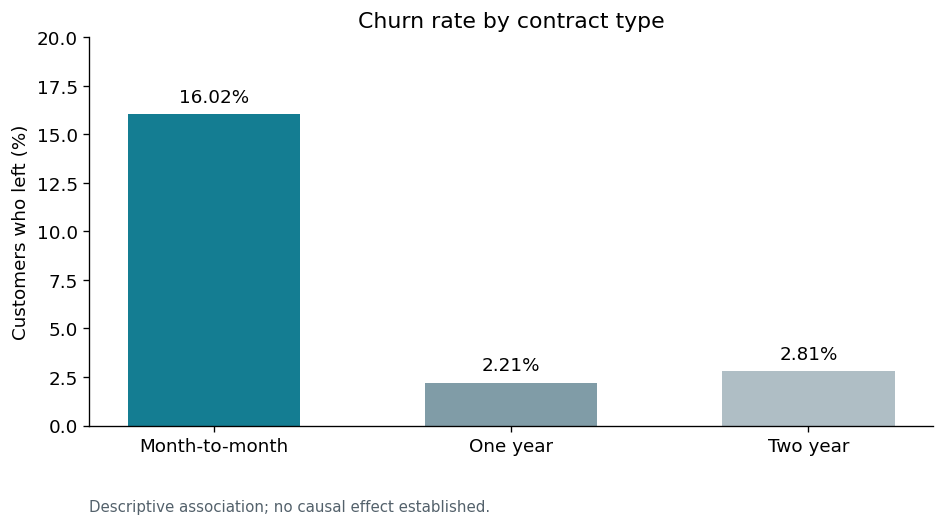

In [2]:
eda = train.assign(Churn=y)
contract_summary = eda.groupby('Contract')['Churn'].agg(customers='size', churners='sum', churn_rate='mean')
payment_summary = eda.groupby('PaymentMethod')['Churn'].agg(customers='size', churners='sum', churn_rate='mean')
tenure_group = pd.cut(train['Tenure'], [-np.inf, 12, 24, np.inf], labels=['12 months or less', 'Over 12 through 24 months', 'Over 24 months'])
tenure_summary = eda.groupby(tenure_group, observed=True)['Churn'].agg(customers='size', churn_rate='mean')
print(contract_summary.to_string(float_format=lambda x: f'{x:.4f}'))
print('\nPayment method:')
print(payment_summary.to_string(float_format=lambda x: f'{x:.4f}'))
print('\nTenure:')
print(tenure_summary.to_string(float_format=lambda x: f'{x:.4f}'))
contract_summary.to_csv(RESULTS / 'churn_by_contract.csv')
payment_summary.to_csv(RESULTS / 'churn_by_payment.csv')

plt.rcParams.update({'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False})
fig, ax = plt.subplots(figsize=(8, 4.6))
order = ['Month-to-month', 'One year', 'Two year']
values = contract_summary.loc[order, 'churn_rate'] * 100
bars = ax.bar(order, values, color=['#147d92', '#809ca7', '#afbec5'], width=.58)
ax.bar_label(bars, labels=[f'{v:.2f}%' for v in values], padding=5)
ax.set(title='Churn rate by contract type', ylabel='Customers who left (%)', ylim=(0, 20))
ax.text(0, -0.22, 'Descriptive association; no causal effect established.', transform=ax.transAxes, fontsize=9, color='#53616b')
fig.tight_layout()
fig.savefig(RESULTS / 'churn_by_contract.png', dpi=160, bbox_inches='tight')
plt.show()


## 3. Initial model comparison
Use a stratified 70/30 split (4,200 training and 1,800 evaluation rows). Tune the same three model families and parameter ranges used in the original submission. Each cross-validation fold fits its own preprocessing. Select the best baseline using mean cross-validation F1, before evaluating the reserved split.

An always-stay dummy model provides context: with roughly 10% churn, high accuracy can coexist with zero ability to identify churners. All classification metrics use the default 0.5 probability threshold.


In [3]:
X_train, X_holdout, y_train, y_holdout = train_test_split(X, y, test_size=0.30, stratify=y, random_state=SEED)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
numeric_cols = X.select_dtypes(include='number').columns.tolist()
category_cols = X.select_dtypes(exclude='number').columns.tolist()
baseline_preprocessor = ColumnTransformer([
    ('numeric', Pipeline([('impute', SimpleImputer(strategy='mean')), ('scale', StandardScaler())]), numeric_cols),
    ('categorical', Pipeline([('impute', SimpleImputer(strategy='most_frequent')), ('encode', OneHotEncoder(handle_unknown='ignore'))]), category_cols)
])
model_specs = {
    'Logistic regression': (LogisticRegression(max_iter=2000, random_state=SEED), {'classifier__C': [0.01, 0.1, 1, 10]}),
    'Decision tree': (DecisionTreeClassifier(random_state=SEED), {'classifier__max_depth': [5, 10], 'classifier__min_samples_split': [2, 10], 'classifier__min_samples_leaf': [1, 5]}),
    'Random forest': (RandomForestClassifier(random_state=SEED, n_jobs=1), {'classifier__n_estimators': [200, 500], 'classifier__max_depth': [5, 10, 20], 'classifier__min_samples_split': [2, 5]})
}
best_models, cv_records = {}, []
for name, (estimator, params) in model_specs.items():
    pipeline = Pipeline([('preprocessor', clone(baseline_preprocessor)), ('classifier', estimator)])
    search = GridSearchCV(pipeline, params, cv=cv, scoring='f1', n_jobs=2, error_score='raise')
    search.fit(X_train, y_train)
    best_models[name] = search.best_estimator_
    cv_records.append({'model': name, 'cv_f1': float(search.best_score_), 'parameters': search.best_params_})
    print(f'{name}: best mean CV F1 = {search.best_score_:.4f}; {search.best_params_}')
best_baseline_name = max(cv_records, key=lambda row: row['cv_f1'])['model']
print('Selected baseline:', best_baseline_name)
pd.DataFrame(cv_records).to_csv(RESULTS / 'cross_validation_results.csv', index=False)


Logistic regression: best mean CV F1 = 0.1690; {'classifier__C': 10}
Decision tree: best mean CV F1 = 0.2003; {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 5, 'classifier__min_samples_split': 2}
Random forest: best mean CV F1 = 0.0141; {'classifier__max_depth': 20, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
Selected baseline: Decision tree


## 4. Ensemble revision
Following the original ensemble idea, engineer spending intensity, a count of explicitly subscribed yes/no services, and a contract/payment interaction. Drop the same three administrative/noise candidates. These design choices were inherited or clarified from the original project; they are not new findings of this rerun.

Each stacking base estimator owns its preprocessing pipeline. scikit-learn's `TargetEncoder` cross-fits training encodings, and the full pipeline is refitted inside each stacking fold. This replaces the original `category_encoders` implementation, so it is a methodological revision, not a reproduction of the previously saved 0.7848 AUC.

The ensemble uses the same evaluation rows as the baselines. No threshold or hyperparameter is chosen from their evaluation results.

Reference: [scikit-learn target encoder cross-fitting example](https://scikit-learn.org/stable/auto_examples/preprocessing/plot_target_encoder_cross_val.html).


In [4]:
def engineer_features(frame):
    result = frame.copy()
    result['SpendingIntensity'] = result['MonthlyCharges'] / (result['Tenure'] + 1)
    # InternetService uses service types rather than Yes/No, so exclude it from this count.
    service_cols = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
    result['ServiceCount'] = result[service_cols].eq('Yes').sum(axis=1)
    result['ContractPaymentRisk'] = result['Contract'].astype(str) + '_' + result['PaymentMethod'].astype(str)
    return result.drop(columns=['RandomIDHash', 'InternalCodeFlag', 'SurveyVersion'])

def ensemble_preprocessor():
    return ColumnTransformer([
        ('numeric', SimpleImputer(strategy='median'), make_column_selector(dtype_include=np.number)),
        ('categorical', TargetEncoder(target_type='binary', cv=5, shuffle=True, random_state=SEED), make_column_selector(dtype_exclude=np.number))
    ])

stacking = StackingClassifier(
    estimators=[
        ('gradient_boosting', Pipeline([('preprocessor', ensemble_preprocessor()), ('classifier', HistGradientBoostingClassifier(random_state=SEED))])),
        ('random_forest', Pipeline([('preprocessor', ensemble_preprocessor()), ('classifier', RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=1))]))
    ],
    final_estimator=LogisticRegression(max_iter=2000, random_state=SEED),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    n_jobs=2
)
stacking.fit(engineer_features(X_train), y_train)
print('Ensemble training complete.')


Ensemble training complete.


## 5. Evaluation
ROC-AUC measures ranking discrimination. Average precision summarizes precision-recall performance and is useful alongside the approximately 10% churn prevalence. Neither is a classification accuracy percentage. Compare all models on the same reserved split; these retrospective estimates still require validation on future or external data.


                      accuracy  precision  recall     f1  roc_auc  average_precision
model                                                                               
Always-stay baseline    0.9011     0.0000  0.0000 0.0000   0.5000             0.0989
Logistic regression     0.9006     0.4667  0.0393 0.0725   0.7575             0.2671
Decision tree           0.8694     0.1724  0.0843 0.1132   0.6627             0.1684
Random forest           0.9011     0.5000  0.0056 0.0111   0.7583             0.2526
Stacking ensemble       0.8989     0.1667  0.0056 0.0109   0.7356             0.2319
Holdout churn prevalence: 0.0989


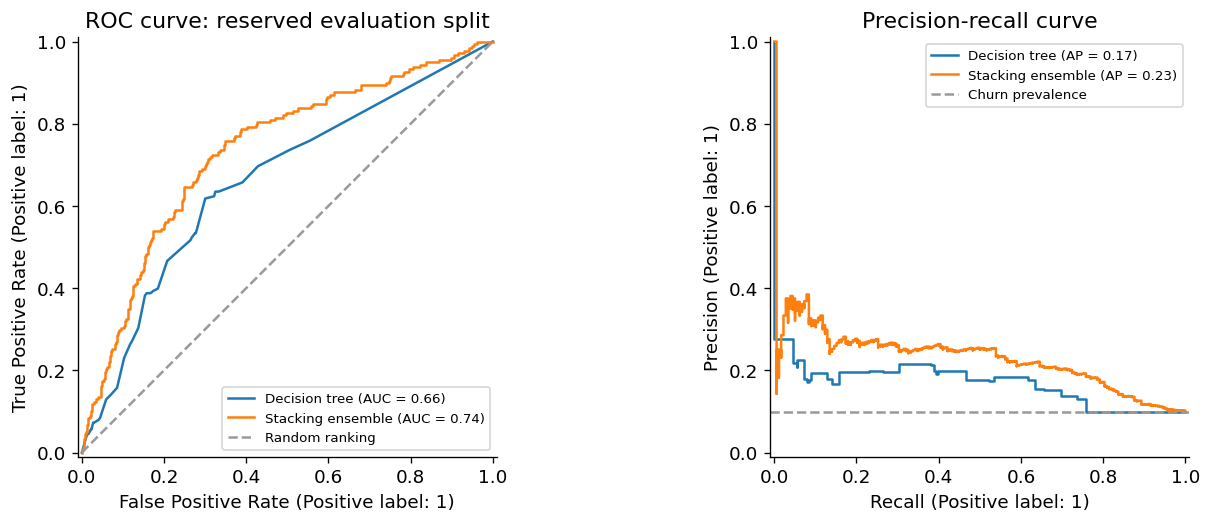

In [5]:
def evaluate(name, model, features):
    probability = model.predict_proba(features)[:, 1]
    prediction = model.predict(features)
    return {'model': name, 'accuracy': accuracy_score(y_holdout, prediction), 'precision': precision_score(y_holdout, prediction, zero_division=0), 'recall': recall_score(y_holdout, prediction, zero_division=0), 'f1': f1_score(y_holdout, prediction, zero_division=0), 'roc_auc': roc_auc_score(y_holdout, probability), 'average_precision': average_precision_score(y_holdout, probability)}, probability

dummy = DummyClassifier(strategy='prior').fit(X_train, y_train)
models_for_evaluation = {'Always-stay baseline': (dummy, X_holdout), **{name: (model, X_holdout) for name, model in best_models.items()}, 'Stacking ensemble': (stacking, engineer_features(X_holdout))}
metric_rows, probabilities = [], {}
for name, (model, features) in models_for_evaluation.items():
    row, probs = evaluate(name, model, features)
    metric_rows.append(row)
    probabilities[name] = probs
metrics = pd.DataFrame(metric_rows).set_index('model')
print(metrics.to_string(float_format=lambda value: f'{value:.4f}'))
print(f'Holdout churn prevalence: {y_holdout.mean():.4f}')
metrics.to_csv(RESULTS / 'model_metrics.csv')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for name in [best_baseline_name, 'Stacking ensemble']:
    RocCurveDisplay.from_predictions(y_holdout, probabilities[name], name=name, ax=axes[0])
    PrecisionRecallDisplay.from_predictions(y_holdout, probabilities[name], name=name, ax=axes[1])
axes[0].plot([0, 1], [0, 1], '--', color='#999999', label='Random ranking')
axes[1].axhline(y_holdout.mean(), linestyle='--', color='#999999', label='Churn prevalence')
axes[0].set_title('ROC curve: reserved evaluation split')
axes[1].set_title('Precision-recall curve')
for ax in axes: ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(RESULTS / 'model_evaluation.png', dpi=160, bbox_inches='tight')
plt.show()


## 6. Interpreting the selected baseline
Permutation importance measures how much the chosen score changes when a feature is shuffled. It is specific to the fitted model, evaluation data, and metric; it is not proof of causation. Correlated features can share or obscure importance. No model changes are made in response to this evaluation-set diagnostic.


In [6]:
importance = permutation_importance(best_models[best_baseline_name], X_holdout, y_holdout, scoring='f1', n_repeats=10, random_state=SEED, n_jobs=2)
importance_table = pd.DataFrame({'feature': X.columns, 'importance_mean': importance.importances_mean, 'importance_std': importance.importances_std}).sort_values('importance_mean', ascending=False)
print(importance_table.head(8).to_string(index=False, float_format=lambda value: f'{value:.4f}'))
importance_table.to_csv(RESULTS / 'baseline_feature_importance.csv', index=False)


           feature  importance_mean  importance_std
   InternetService           0.0456          0.0146
          Contract           0.0410          0.0205
NumPaymentFailures           0.0164          0.0073
     PaymentMethod           0.0147          0.0172
      RandomIDHash           0.0068          0.0037
     SeniorCitizen           0.0035          0.0131
            Tenure           0.0022          0.0037
     PromoCategory           0.0022          0.0053


## 7. Business interpretation and limitations

- Month-to-month customers have a higher observed churn rate than annual-contract customers. Investigate their service experience and reasons for leaving before choosing a retention offer.
- Use precision and recall alongside ranking metrics: a default classification threshold may identify too few churners for practical outreach.
- Test retention offers with a controlled experiment. This dataset does not show that discounts or longer contracts will reduce churn.
- No outreach cost, customer value, or intervention response data is supplied, so this project does not estimate profit or prescribe a production decision threshold.
- Feature availability at prediction time and the original dataset provenance need confirmation. Future data could differ from this classroom dataset.
- Any further model or threshold choices should be made within training/validation data, followed by evaluation on fresh data.

## 8. Predictions for the unlabeled file
Refit the pre-specified ensemble on all 6,000 labeled rows after evaluation, then score the 1,000 unlabeled rows. This is an experimental scoring output, not a deployment recommendation. IDs below are generated row numbers, not verified customer IDs.


In [7]:
final_scoring_model = clone(stacking)
final_scoring_model.fit(engineer_features(X), y)
churn_probability = final_scoring_model.predict_proba(engineer_features(unlabeled))[:, 1]
assert len(churn_probability) == len(unlabeled)
assert np.isfinite(churn_probability).all()
assert ((churn_probability >= 0) & (churn_probability <= 1)).all()
predictions = pd.DataFrame({'id': np.arange(1, len(unlabeled) + 1), 'prediction': churn_probability})
predictions.to_csv(RESULTS / 'predictions_final.csv', index=False)
summary = {'labeled_rows': len(train), 'unlabeled_rows': len(unlabeled), 'features': X.shape[1], 'churners': int(y.sum()), 'churn_rate': float(y.mean()), 'holdout_rows': len(y_holdout), 'holdout_churners': int(y_holdout.sum()), 'selected_baseline': best_baseline_name, 'cv_results': cv_records, 'metrics': metric_rows, 'python': platform.python_version(), 'sklearn': sklearn.__version__}
(RESULTS / 'run_summary.json').write_text(json.dumps(summary, indent=2))
print(f'Saved {len(predictions):,} probability predictions in results/predictions_final.csv')
print('All probabilities are finite and between 0 and 1.')


Saved 1,000 probability predictions in results/predictions_final.csv
All probabilities are finite and between 0 and 1.
